# Exercise Evaluation

**Mario Álvarez Martínez**

**Marcos Carrasco Panadero**

**Sergio Samaniego Hernández**

## Exercise 1 — Test Costs and Misclassification Costs (BreastCancer)

Use the **BreastCancer** dataset and the provided **train/test** partition.

### Given
1. **Attribute test costs**  
   You are given an array `testcosts` where each position corresponds to the cost of measuring one attribute:
   - `testcosts[0]` → **Cl.thickness**
   - `testcosts[1]` → **Cell.size**
   - …
   - and so on for the remaining attributes in order.

2. **Misclassification costs** (cost-sensitive classification)  
   Use the following cost matrix:
   - Predict **benign** when the true class is **malignant** (false negative): **20**
   - Predict **malignant** when the true class is **benign** (false positive): **4**
   - Correct predictions: **0**

### Objective
Design a classifier that **minimizes the total (global) cost**, defined as:

> **Global cost = test cost + misclassification cost**

where:
- **test cost** is the sum of the costs of the attributes used (or acquired) by the model, and
- **misclassification cost** is computed on the **test set** using the cost matrix above.

---

### Important requirement: use a *clever* search strategy (not brute force)

You should **not** solve this by exhaustively trying all feature subsets (which is essentially brute force and does not scale).
Instead, your approach should use an **informed, efficient strategy** to discover good trade-offs between:
- **low test cost** (cheap measurements), and
- **low misclassification cost** (better decisions under asymmetric error costs).


---

### What to do
Explore multiple model/design options that trade off:
- using **cheaper vs. more expensive** subsets of attributes (feature subsets or acquisition policies), and
- **classification performance** under the given misclassification costs.

Try to use **test and missclasification costs** in training time in order to reduce the final overall cost

For each option, report:
- **Total test cost**
- **Total misclassification cost**
- **Global cost** (sum of both)

### Deliverable
Produce a plot showing the trade-off across explored options:

> **x-axis:** total test cost  
> **y-axis:** total misclassification cost  

Optionally:
- annotate points with **global cost**, and
- highlight the configuration with the **lowest global cost** and the **Pareto-efficient** options.


In [2]:
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_openml

from sklearn.model_selection import train_test_split

testscosts = [2, 4, 3, 1, 5, 3, 2, 4, 2, 0]
bc = fetch_openml(data_id=15, as_frame=True)
df = bc.frame.copy()

# 1) Drop ID if present (mlbench removes first column)
possible_id_cols = ["Id", "id", "Sample_code_number", "sample_code_number"]
id_cols = [c for c in df.columns if c in possible_id_cols]
if id_cols:
    df = df.drop(columns=id_cols)

# 2) Mimic complete.cases(): treat "?" as missing, then drop rows with any missing
df = df.replace("?", np.nan).dropna()

# 3) Split X/y
y = df["Class"]
X = df.drop(columns=["Class"])

# (optional) ensure numeric predictors
X = X.apply(pd.to_numeric, errors="raise")
print(X.shape)

SEED=480
# 1) Split off Train1 = 75%, and the remaining 25%
X_train1, X_test, y_train1, y_test = train_test_split(
    X, y,train_size=0.75,random_state=SEED,stratify=y)

print("Train1:", X_train1.shape, y_train1.shape)  # ~75%
print("Test:  ", X_test.shape, y_test.shape)      # ~25%

# Optional sanity check: exact proportions
n = len(X)
print("Proportions:",
      len(X_train1)/n,  len(X_test)/n)

df

(683, 9)
Train1: (512, 9) (512,)
Test:   (171, 9) (171,)
Proportions: 0.7496339677891655 0.25036603221083453


,Clump_Thickness,Cell_Size_Uniformity,Cell_Shape_Uniformity,Marginal_Adhesion,Single_Epi_Cell_Size,Bare_Nuclei,Bland_Chromatin,Normal_Nucleoli,Mitoses,Class
0,5,1,1,1,2,1.0,3,1,1,benign
1,5,4,4,5,7,10.0,3,2,1,benign
2,3,1,1,1,2,2.0,3,1,1,benign
3,6,8,8,1,3,4.0,3,7,1,benign
4,4,1,1,3,2,1.0,3,1,1,benign
...,...,...,...,...,...,...,...,...,...,...
694,3,1,1,1,3,2.0,1,1,1,benign
695,2,1,1,1,2,1.0,1,1,1,benign
696,5,10,10,3,7,3.0,8,10,2,malignant
697,4,8,6,4,3,4.0,10,6,1,malignant


### 1.2 Methodology

This problem requires **cost-sensitive learning** on two fronts simultaneously:

1. **Asymmetric misclassification costs** — a false negative (malignant missed as benign) costs 20 units, whereas a false positive (benign flagged as malignant) costs only 4 units. A standard accuracy-optimizing classifier will not account for this asymmetry.

2. **Attribute test costs** — measuring each clinical variable has a real cost. The goal is therefore not just to classify well, but to do so using the cheapest possible subset of features.

The **global cost** we minimize is:

> `global_cost = test_cost × n_instances + misclassification_cost`

#### Feature selection strategy

We use a **greedy forward selection** approach: starting from an empty feature set, at each step we add the one feature that produces the largest reduction in global cost. This is repeated until all 9 features have been added, yielding 9 candidate feature subsets of increasing size (and cost).

This greedy strategy was chosen over alternatives such as:
- **Logistic regression coefficients** — they reflect discriminative power but do not directly encode cost reduction.
- **Knapsack-style dynamic programming** — difficult to define the "benefit" of a feature independently of the others.

The greedy approach does not guarantee a globally optimal subset, but provides a principled and scalable approximation.

#### Handling asymmetric misclassification costs

At each greedy step, three strategies for incorporating the cost asymmetry are evaluated, and the one yielding the lowest global cost is selected:

| Strategy | Description |
|---|---|
| **Thresholding** | Train with default threshold (0.5), then shift the decision boundary to the theoretical optimum: `th = C_FP / (C_FP + C_FN)` |
| **Rebalancing (weights)** | Train with class weights proportional to the cost ratio, penalizing misclassification of the malignant class more heavily |
| **Rebalancing (oversampling)** | Oversample the malignant class in the training set according to the cost ratio, then train a standard classifier |

The two classifiers used throughout are a **Decision Tree** (`max_depth=3`) and **Logistic Regression**.

Lo primero será crear una serie fe funciones que ayudán para la optimización del misclassification cost.

### 1.3 Auxiliary Functions

Before running the greedy search, we define the helper functions used throughout:
- The **cost matrix** and scalar constants `C_FP`, `C_FN`.
- `cost_error` — computes total misclassification cost from predictions.
- `apply_cost_threshold` — applies a custom probability threshold to `predict_proba` output.
- `compute_all_metrics` — returns a summary dict of cost and performance metrics.
- `subset_test_cost` — computes the total test cost for a given feature subset.


In [3]:
# =========================
# Definition of our COST MATRIX
# =========================

#Positive class = malignant
#Negative class = benign

#                  True malignant   True benign
# Pred malignant        0               4        <- FP: false alarm
# Pred benign          20               0        <- FN: missed malignant

cost_matrix = np.array([[0,4],[20,0]], dtype=float)

C_FP = cost_matrix[0, 1] # Cost of predicting 'malignant' when actually is 'benign': 4 
C_FN = cost_matrix[1, 0] # Cost of predicting 'benign' when actually is 'malignant': 20
cost_matrix = np.array([[0, 4],
                        [20, 0]], dtype=float)


threshold_theoretical = C_FP / (C_FP + C_FN)  # 4 / 24 = 0.1666...


# =========================
# COST ERROR
# =========================
def cost_error(y_test, y_pred):
    """
    Uses the values from the cost matrix to produce the cost error from the confusion matrix.
    """
    y_test, y_pred = np.array(y_test), np.array(y_pred)
    
    fp = np.sum((y_test == "benign") & (y_pred == "malignant"))
    fn = np.sum((y_test == "malignant") & (y_pred == "benign"))
    
    return int(fn * C_FN + fp * C_FP)

# =========================
# THRESHOLDING
# =========================
def apply_cost_threshold(y_prob, threshold):
    """
    Converts predict_proba() python's output to class labels using a custom threshold.

    sklearn orders classes alphabetically: [benign, malignant]
    So column 0 = P(benign), column 1 = P(malignant).

    Decision rule:
        If P(malignant) >= threshold  ->  predict 'malignant'
        If P(malignant) <  threshold  ->  predict 'benign'

    Returns:
    y_pred: array of strings ('malignant' or 'benign')
    """
    prob_malignant = y_prob[:, 1] # Extracts the probability of malignant for each sample
    predicts_malignant = prob_malignant >= threshold # Applies the threshold: True where model  should predict malignant
    y_pred = np.where(predicts_malignant, "malignant", "benign") # Converts boolean array to string class labels
    return y_pred


# =========================
# AUXILIAR METRICS
# =========================
from sklearn.metrics import (confusion_matrix, accuracy_score, f1_score, roc_curve, auc, RocCurveDisplay)

def compute_all_metrics(y_true, y_pred, strategy_name):
    """
    Returns a dict with all metrics for a given set of predictions.

    Metrics:
        cost_error  : total misclassification cost (main objective)
        mmce        : mean misclassification error = 1 - accuracy
                      (same as 'mmce' in mlr R package)
        accuracy    : fraction of correct predictions
        f1_macro    : macro-averaged F1 across both classes
        f1_malignant: F1 for the positive class (malignant) only
    """
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    false_negatives = np.sum((y_true == "malignant") & (y_pred == "benign"))
    false_positives = np.sum((y_true == "benign")    & (y_pred == "malignant"))
    accuracy = accuracy_score(y_true, y_pred)

    return {
        "strategy": strategy_name,
        "cost_error": cost_error(y_true, y_pred),
        "mmce":round(1 - accuracy, 4),
        "accuracy":round(accuracy, 4),
        "f1_macro": round(f1_score(y_true, y_pred, average="macro"), 4),
        "f1_malignant": round(f1_score(y_true, y_pred, pos_label="malignant", average="binary"), 4),
        "cost_matrix": confusion_matrix(y_true, y_pred)
    }


# =========================
# TEST COST
# =========================
def subset_test_cost(feature_subset, cost_dict, n_instances):
    """
    Total cost of measuring all variables in feature_subset en every evaluated instance.
    """
    return float(sum(cost_dict[f] for f in feature_subset) * n_instances)

### 1.4 Misclassification Cost Strategies — Preliminary Comparison

Before running the full greedy search, we compare the three cost-handling strategies on the **full feature set**. This gives us an intuition for how much each strategy improves over the unconstrained baseline, and validates the implementations.

The **theoretical optimal threshold** is derived from the indifference point between the two error types:

> `C_FN × P(malignant) = C_FP × P(benign)`  
> ⟹ `threshold = C_FP / (C_FP + C_FN) = 4 / 24 ≈ 0.167`

By lowering the threshold below 0.5, we classify more samples as malignant, trading some false positives for fewer (much costlier) false negatives.



#### Strategy 1 — Thresholding

The model is trained normally but the **decision threshold is shifted** to the theoretical cost-optimal value `≈ 0.167`. A sample is predicted malignant whenever `P(malignant) ≥ 0.167`, making the classifier more aggressive classifying potential malignancies (which is desirable given the high cost of false negatives).




In [4]:
threshold = C_FP / (C_FP + C_FN) #0.167

dt = DecisionTreeClassifier(max_depth=3, criterion="entropy", random_state=0)

def strategy_thresholding(model, X_train, y_train, X_test, y_test, threshold, strategy="Thresholding"):
    """
    Trains the model normally and shifts the decision threshold to the cost-optimal value: th = C_FP / (C_FP + C_FN).
    """
    model.fit(X_train, y_train)
    y_prob = model.predict_proba(X_test)
    y_pred = apply_cost_threshold(y_prob, threshold)
    return compute_all_metrics(y_test, y_pred, strategy)

prueba1 = strategy_thresholding(dt, X_train1, y_train1, X_test, y_test, threshold)
for key, value in prueba1.items():
    print(f"{key}: {value}")


NameError: name 'DecisionTreeClassifier' is not defined

#### Strategy 2 — Rebalancing with class weights

The cost asymmetry is incorporated **directly into training** by assigning class weights proportional to the cost ratio: `weight_malignant = (1 - threshold) / threshold`. The learning algorithm therefore is penalized more heavily for misclassifying malignant instances during tree construction.



In [ ]:
def strategy_rebalancing_weights(model, X_train, y_train, X_test, y_test, threshold, strategy="Rebalancing with class weights"):
    """
    Trains the model with class weights proportional to the cost ratio:
        weight_malignant = (1 - threshold) / threshold
    so that the learner is penalized more for missing malignant instances.
    """
    weight_malignant = (1 - threshold) / threshold  
    
    model.set_params(class_weight={"benign": 1, "malignant": weight_malignant})
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    return compute_all_metrics(y_test, y_pred, strategy)

prueba2 = strategy_rebalancing_weights(dt, X_train1, y_train1, X_test, y_test, threshold)
for key, value in prueba2.items():
    print(f"{key}: {value}")

strategy: Rebalancing with class weights
cost_error: 112
mmce: 0.0702
accuracy: 0.9298
f1_macro: 0.9241
f1_malignant: 0.9032
cost_matrix: [[103   8]
 [  4  56]]


#### Strategy 3 — Rebalancing with oversampling

A third approach: **oversample the minority (malignant) class** in the training set until its effective representation matches the cost-optimal ratio. The classifier is then trained on this rebalanced dataset without any explicit weighting or threshold adjustment.

In [ ]:
from sklearn.utils import resample

def strategy_oversampling(model, X_train, y_train, X_test, y_test, threshold, strategy="Rebalancing with oversampling", seed=SEED):
    """
    Oversamples the malignant class in the training set by a factor of
        weight_malignant = (1 - threshold) / threshold
    then trains a standard (unweighted) classifier on the rebalanced set.
    """
    weight_malignant = (1 - threshold) / threshold

    # Separate train set by classes
    X_train_mal = X_train[y_train == "malignant"]
    y_train_mal = y_train[y_train == "malignant"]
    X_train_ben = X_train[y_train == "benign"]
    y_train_ben = y_train[y_train == "benign"]

    # Oversample malignant to be 'weight_malignant' times its original size
    n_malignant_oversampled = int(len(X_train_mal) * weight_malignant)
    X_mal_oversampled, y_mal_oversampled = resample(
        X_train_mal, y_train_mal,
        replace=True,
        n_samples=n_malignant_oversampled,
        random_state=seed
    )
    
    # Combine back with benign
    X_train_oversample = pd.concat([X_train_ben, X_mal_oversampled])
    y_train_oversample = pd.concat([y_train_ben, y_mal_oversampled])

    model.set_params(class_weight=None)
    model.fit(X_train_oversample, y_train_oversample)
    y_pred = model.predict(X_test)
    return compute_all_metrics(y_test, y_pred, strategy)

prueba3 = strategy_oversampling(dt, X_train1, y_train1, X_test, y_test, threshold)
for key, value in prueba3.items():
    print(f"{key}: {value}")

STRATEGIES = [strategy_thresholding, strategy_rebalancing_weights, strategy_oversampling]

strategy: Rebalancing with oversampling
cost_error: 104
mmce: 0.0585
accuracy: 0.9415
f1_macro: 0.9363
f1_malignant: 0.918
cost_matrix: [[105   6]
 [  4  56]]


### 1.5 Feature Selection strategy

With the three cost strategies defined, we can now run the main search.

The algorithm starts from an **empty feature set** and iterates 9 times (once per available feature). At each step:

1. Every remaining feature is considered as a candidate to add.
2. For each candidate, the three cost strategies are evaluated on the current subset + candidate.
3. The **global cost** is computed as:

> `global_cost = subset_test_cost(feature_subset, cost_dict, n_test) + cost_error`

4. The `(feature, strategy)` pair that yields the **lowest global cost** is selected and committed.

This produces 9 configurations of increasing feature set size, each annotated with: the model used, the winning strategy, the test cost, the misclassification cost, and the global cost.

The process is repeated independently for as many classifiers we want, our case is: **DecisionTree** and **LogisticRegression**.

In [ ]:
import copy

def feature_selection(model, X_train, y_train, X_test, y_test,
                              cost_dict, threshold, seed=SEED):
    """
    Iterates once per feature in cost_dict. At each step, every not-yet-selected
    feature is tested combined with each of the 3 cost strategies. The
    (feature, strategy) pair with the lowest global_cost is the winner.

    Parameters-----------
    model      : unfitted sklearn estimator
    X_train    : training features 
    y_train    : training labels
    X_test     : test features
    y_test     : test labels
    cost_dict  : dict  { feature_name : unit_test_cost }
    threshold  : cost-optimal decision threshold (threshold_theoretical)
    seed       : random seed forwarded to strategy_oversampling

    Returns-----------
    List of dicts, one per feature added. Each dict has:
        n_features    : number of features used at this step
        features      : list of selected feature names
        error_strategy: name of the winning cost strategy
        model_config  : dict with the model class name and its hyperparameters
        test_cost     : total attribute measurement cost over the test set
        cost_error    : total misclassification cost over the test set
        global_cost   : test_cost + cost_error
    """

    n_test    = len(X_test)               # needed to scale unit test costs
    remaining = list(cost_dict.keys())    # features not yet selected
    selected  = []                        # features committed so far
    results   = []                        # one result dict per step

    for step in range(len(cost_dict)):

        best_global_cost = np.inf   # track the best (lowest) global cost seen
        best_feature     = None     # feature that achieved it
        best_metrics     = None     # full metrics dict from compute_all_metrics
        best_test_cost   = None     # test cost of the winning subset

        for feat in remaining:
            # Build the candidate subset by tentatively adding this feature
            candidate_subset = selected + [feat]
            X_tr_sub = X_train[candidate_subset]  # slice train to candidate cols
            X_te_sub = X_test[candidate_subset]   # slice test  to candidate cols

            # Compute the test cost for this candidate subset
            tc = subset_test_cost(candidate_subset, cost_dict, n_test)

            # Try all 3 cost strategies and keep the best
            for strategy_fn in STRATEGIES:
                m = copy.deepcopy(model)  # fresh copy so strategies don't interfere

                # strategy_oversampling needs the seed argument; the other two don't
                if strategy_fn.__name__ == "strategy_oversampling":
                    metrics = strategy_fn(m, X_tr_sub, y_train,
                                         X_te_sub, y_test, threshold, seed=seed)
                else:
                    metrics = strategy_fn(m, X_tr_sub, y_train,
                                         X_te_sub, y_test, threshold)

                gc = tc + metrics["cost_error"]  # global cost for this combination

                if gc < best_global_cost:
                    best_global_cost = gc
                    best_feature     = feat
                    best_metrics     = metrics
                    best_test_cost   = tc

        #Append the winning feature for this step
        selected.append(best_feature)
        remaining.remove(best_feature)

        #Collect the model's class name and its fitted hyperparameters
        model_config = {"model"  : type(model).__name__, "params" : model.get_params()}

        results.append({
            "n_features"    : len(selected),
            "features"      : selected.copy(),
            "error_strategy": best_metrics["strategy"],
            "model_config"  : model_config,
            "test_cost"     : best_test_cost,
            "cost_error"    : best_metrics["cost_error"],
            "global_cost"   : best_global_cost,
        })

        print(f"Step {step+1:2d} | +{best_feature:<25s} | "
              f"strategy: {best_metrics['strategy']:<35s} | "
              f"test_cost: {best_test_cost:7.0f} | "
              f"cost_error: {best_metrics['cost_error']:5d} | "
              f"global_cost: {best_global_cost:7.0f}")

    return results

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

print("=" * 100)
print("DECISION TREE")
print("=" * 100)
dt_model = DecisionTreeClassifier(max_depth=3, criterion="entropy", random_state=0)
results_dt = feature_selection(dt_model, X_train1, y_train1, X_test, y_test,dic_var_cost, threshold_theoretical)

print()
print("=" * 100)
print("LOGISTIC REGRESSION")
print("=" * 100)
lr_model = LogisticRegression(fit_intercept=True, max_iter=1000)
results_lr = feature_selection(lr_model, X_train1, y_train1, X_test, y_test,dic_var_cost, threshold_theoretical)

DECISION TREE
Step  1 | +Marginal_Adhesion         | strategy: Thresholding                        | test_cost:     171 | cost_error:   280 | global_cost:     451
Step  2 | +Clump_Thickness           | strategy: Rebalancing with oversampling       | test_cost:     513 | cost_error:   148 | global_cost:     661
Step  3 | +Bland_Chromatin           | strategy: Thresholding                        | test_cost:     855 | cost_error:    84 | global_cost:     939
Step  4 | +Mitoses                   | strategy: Thresholding                        | test_cost:    1197 | cost_error:    84 | global_cost:    1281
Step  5 | +Cell_Shape_Uniformity     | strategy: Rebalancing with oversampling       | test_cost:    1710 | cost_error:    44 | global_cost:    1754
Step  6 | +Bare_Nuclei               | strategy: Thresholding                        | test_cost:    2223 | cost_error:   104 | global_cost:    2327
Step  7 | +Cell_Size_Uniformity      | strategy: Thresholding                        | test_

### 1.6 Results — Cost Trade-off Plot

We can represent the results in a table as shown above but it would be better to plot them. Each point in the plot below represents one of the 9 feature subset configurations produced by the feature selection search, for each model. The axes are:

- **x-axis**: `test_cost` — total cost of measuring the selected attributes across all test instances.
- **y-axis**: `cost_error` — total misclassification cost on the test set.


However, minimising `global_cost` alone hides details (two configurations can share the same global cost value yet differ greatly in composition). Depending on the context (budget constraints, tolerance for missed predictions), a client might rationally prefer a cheaper-but-less-accurate model over an expensive-but-precise one. This is why we also draw the **Pareto frontier**.

A configuration is **Pareto-efficient** if no other configuration is strictly better on *both* axes simultaneously. . The frontier (drawn as a dashed line) exposes the full set of rational trade-offs:
each step represents paying more in `test_cost` to gain a reduction in `cost_error`. Any point not on the frontier is dominated and can be discarded regardless of preferences.

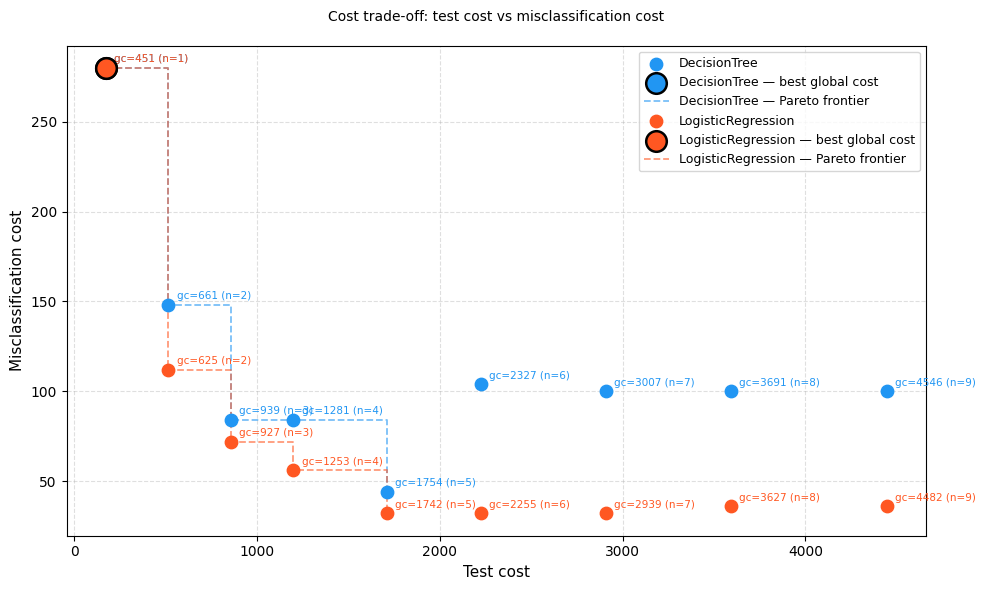

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def pareto_frontier(results):
    """
    Returns the Pareto-efficient configurations in a list.
    A point is Pareto-efficient if no other point is strictly better
    on test_cost and cost_error simultaneously.
    """
    # Sort by test_cost ascending; among ties, cost_error ascending
    sorted_results = sorted(results, key=lambda r: (r["test_cost"], r["cost_error"]))
    pareto = []
    min_cost_error_seen = np.inf
    for r in sorted_results:
        if r["cost_error"] < min_cost_error_seen:
            pareto.append(r)
            min_cost_error_seen = r["cost_error"]
    return pareto


def plot_cost_tradeoff(results_dt, results_lr):
    """
    Scatter plot of test_cost (x) vs cost_error (y) for all greedy
    configurations produced by greedy_feature_selection, for both models.

    Each point = one greedy step (one feature subset).
    Annotations show the global_cost of each configuration.
    The configuration with the lowest global_cost per model is highlighted
    with a black edge. The Pareto frontier is drawn as a dashed step line.
    """

    fig, ax = plt.subplots(figsize=(10, 6))

    colors  = {"DecisionTree": "#2196F3", "LogisticRegression": "#FF5722"}

    for model_name, results in [("DecisionTree", results_dt), ("LogisticRegression", results_lr)]:
        tc_vals = [r["test_cost"]   for r in results]
        ce_vals = [r["cost_error"]  for r in results]
        gc_vals = [r["global_cost"] for r in results]
        n_vals  = [r["n_features"]  for r in results] # n = number of variables of each feature seleciton

        color  = colors[model_name]

        #base scatter
        ax.scatter(tc_vals, ce_vals, color=color, s=80, zorder=3, label=model_name)

        #annotate each point with global_cost and n_features
        for tc, ce, gc, n in zip(tc_vals, ce_vals, gc_vals, n_vals):
            ax.annotate(f"gc={gc:.0f} (n={n})", (tc, ce),
                        textcoords="offset points", xytext=(6, 4),
                        fontsize=7.5, color=color)

        #highlight the configuration with the lowest global_cost
        best = min(results, key=lambda r: r["global_cost"])
        ax.scatter(best["test_cost"], best["cost_error"],
                   color=color,
                   s=220, edgecolors="black", linewidths=1.8,
                   zorder=4, label=f"{model_name} — best global cost")

        #Pareto frontier as a step line
        pareto = pareto_frontier(results)
        if len(pareto) > 1:
            pf_tc = [r["test_cost"]  for r in pareto]
            pf_ce = [r["cost_error"] for r in pareto]
            ax.step(pf_tc, pf_ce, where="post",
                    color=color, linewidth=1.3, linestyle="--", alpha=0.6,
                    label=f"{model_name} — Pareto frontier")

    ax.set_xlabel("Test cost", fontsize=11)
    ax.set_ylabel("Misclassification cost", fontsize=11)
    ax.set_title("Cost trade-off: test cost vs misclassification cost\n",fontsize=10)
    ax.legend(fontsize=9, loc="upper right")
    ax.grid(True, linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.show()

plot_cost_tradeoff(results_dt, results_lr)

## Exercise 2 — Open Set Recognition (Digits)

### Goal
Set up an **open set** experiment with a digit dataset (10 classes, 0–9).

You will:
- Train a classifier using **only 8 digits** (the *known* classes).
- Test on a mixture of **known** and **unknown** digits (the *unknown* classes were never seen in training).
- Produce the required **curves** and compute **open-set metrics**.

### Protocol (fixed)
- **Known classes:** {0,1,2,3,4,5,6,7}  
- **Unknown classes:** {8,9}

### What you must deliver
1. A trained model on the **known** training set.
2. Some **strategies** to determine for each test sample that indicates how “known-like” it is (higher = more likely to be known).
3. The following curves (students must draw them):
   - **ROC curve** for *known vs unknown* detection (choose your positive/negative convention and state it).
   - **OSCR curve**: **CCR** (Correct Classification Rate on knowns) vs **FPR** (False Positive Rate on unknowns), obtained by sweeping a threshold on your detection score.
4. Compute at least:
   - **AUROC** for open-set detection (known vs unknown)
   - **OSCR** (area under the OSCR curve)
5. Explore **other metrics** of your choice (e.g., AUPR, FPR@95%TPR, macro-F1 on accepted-knowns, etc.) and discuss what they capture.

> Important: do **not** treat the task as a normal 10-class closed-set problem.  
> Unknown samples should be handled as *unknown at test time* (rejection / abstention via a threshold on your score).


In [ ]:
import numpy as np
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

# -----------------------------
# Data loading
# -----------------------------
digits = load_digits()
X = digits.data.astype(np.float64)   # (n_samples, 64)
y = digits.target.astype(int)        # labels 0..9

# -----------------------------
# Open set protocol (fixed)
# -----------------------------
known_classes = np.arange(0, 8)     # 0..7
unknown_classes = np.arange(8, 10)  # 8,9

mask_known = np.isin(y, known_classes)
mask_unknown = np.isin(y, unknown_classes)

X_known, y_known = X[mask_known], y[mask_known]
X_unknown, y_unknown = X[mask_unknown], y[mask_unknown]

# -----------------------------
# Train/test split ONLY on known classes
# -----------------------------
# Keep unknown classes completely out of training.
Xk_train, Xk_test, yk_train, yk_test = train_test_split(
    X_known, y_known,
    test_size=0.30,
    random_state=280,
    stratify=y_known
)

# Unknowns are used ONLY for testing (open-set evaluation)
Xu_test, yu_test = X_unknown, y_unknown

print('Known train:', Xk_train.shape, 'Known test:', Xk_test.shape, 'Unknown test:', Xu_test.shape)

# -----------------------------
# TODO (students)
# -----------------------------
# 1) Train your classifier on (Xk_train, yk_train).
# 2) Produce predictions for known-test: yk_pred on Xk_test.
# 3) Define a scalar "knownness" score for each sample:
#       sk_known  = score(Xk_test)    # higher => more likely known
#       sk_unk    = score(Xu_test)
# 4) Sweep a threshold tau over the scores and compute:
#       - ROC points for detection (known vs unknown)
#       - OSCR points: CCR(tau) vs FPR(tau)
# 5) Compute AUROC and OSCR (areas under the curves).
# 6) Explore at least one additional open-set metric and report it.

# Tip: keep these arrays as your standard interface:
# sk_known: shape (n_known_test,)
# sk_unk:   shape (n_unknown_test,)
# yk_pred:  shape (n_known_test,)
# yk_test:  shape (n_known_test,)


[[ 0.  0.  5. ...  0.  0.  0.]
 [ 0.  0.  0. ... 10.  0.  0.]
 [ 0.  0.  0. ... 16.  9.  0.]
 ...
 [ 0.  0.  1. ...  6.  0.  0.]
 [ 0.  0.  2. ... 12.  0.  0.]
 [ 0.  0. 10. ... 12.  1.  0.]]
[0 1 2 ... 8 9 8]
Known train: (1010, 64) Known test: (433, 64) Unknown test: (354, 64)


### 2.1 Training the base model


In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Pipeline: normalización + MLP
model = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPClassifier(
        hidden_layer_sizes=(256, 128),
        activation='relu',
        max_iter=500,
        random_state=42,
        early_stopping=True,
        validation_fraction=0.1))])

model.fit(Xk_train, yk_train)


Accuracy closed-set (known test): 0.9861


### 2.2 Produce predictions for known-test: yk_pred on Xk_test


In [ ]:
from sklearn.metrics import accuracy_score

yk_pred = model.predict(Xk_test)

print(f"Accuracy known-set (known test): {accuracy_score(yk_test, yk_pred):.4f}")

Accuracy known-set (known test): 0.9861


### 2.3 Defining a scalar "knownness" score for each sample

Para el Open Set Recognition necesitamos asignar a cada muestra un score  que indique cuán probable es que pertenezca a una clase conocida. A mayor score ---> más probable que sea known.

Implementamos dos estrategias (hay 3 en total según la teoría):

#### 2.3.1 Strategy 1. Maximum Class Probability: Confidence Thresholding

In [ ]:
probs_known = model.predict_proba(Xk_test)
sk_known_strat1 = np.max(probs_known, axis=1)

probs_unk = model.predict_proba(Xu_test)
sk_unk_strat1 = np.max(probs_unk, axis=1)

print("Strategy 1 - Max Class Probability:")
print(f"  Mean score for Knowns:   {np.mean(sk_known_strat1):.4f}")
print(f"  Mean score for Unknowns: {np.mean(sk_unk_strat1):.4f}")

#### 2.3.2 Strategy 2. Distance-based method: Negative Distance to Nearest Class Centroid

In [ ]:
clf_centroids = NearestCentroid()
clf_centroids.fit(Xk_train, yk_train)

dist_matrix_k = clf_centroids.transform(Xk_test)
dist_matrix_u = clf_centroids.transform(Xu_test)

sk_known_strat2 = -np.min(dist_matrix_k, axis=1)
sk_unk_strat2 = -np.min(dist_matrix_u, axis=1)

print("Strategy 2 - Distance-based (Marcos) completed.")

### 2.4 Evaluating 

¿Cómo se evalúa el Open Set?

La evaluación se hace **barriendo un umbral τ** sobre el score de cada muestra:
- Si `score(x) ≥ τ` → la muestra se **acepta** como *known* (y se clasifica en la clase predicha).
- Si `score(x) < τ` → la muestra se **rechaza** como *unknown*.

Con este barrido construimos dos curvas:



#### Curva ROC (Known vs Unknown detection)

Tratamos el problema como **detección binaria**:
- **Positivo** = muestra *known* (clases 0–7)
- **Negativo** = muestra *unknown* (clases 8–9)

Métricas:
- **TPR** (True Positive Rate / Recall sobre knowns): fracción de knowns aceptados correctamente.
- **FPR** (False Positive Rate): fracción de unknowns aceptados erróneamente.

**AUROC** = área bajo esta curva. Un valor de 1.0 significa separación perfecta.

In [ ]:
def compute_roc_openset(scores_known, scores_unk):
    """
    Computes the points for the Receiver Operating Characteristic (ROC) curve 
     and the Area Under the ROC (AUROC) specifically for the Open Set Recognition (OSR) scenario.
    
    Parameters:
    - scores_known (array-like): Confidence scores assigned by the model to samples from known classes.
    - scores_unk (array-like): Confidence scores assigned by the model to samples from unknown classes.
    
    Returns:
    - tprs (np.array): True Positive Rates (Recall on knowns) for each threshold.
    - fprs (np.array): False Positive Rates (Unknowns accepted) for each threshold.
    - auroc (float): The calculated Area Under the ROC curve.
    """
    thresholds = np.unique(np.concatenate([scores_known, scores_unk]))
    thresholds = np.sort(thresholds)[::-1]
    
    tprs = [] 
    fprs = [] 
    
    n_known = len(scores_known)
    n_unk = len(scores_unk)
    
    for tau in thresholds:
        tpr = np.sum(scores_known >= tau) / n_known
        fpr = np.sum(scores_unk >= tau) / n_unk
        
        tprs.append(tpr)
        fprs.append(fpr)
    
    tprs = np.array(tprs)
    fprs = np.array(fprs)
    
    auroc = np.trapz(tprs, fprs)
    
    return tprs, fprs, auroc

#### Curva OSCR (Open Set Classification Rate)

La curva OSCR es más exigente: no basta con *aceptar* una muestra known, hay que *clasificarla correctamente*:

- **CCR** (Correct Classification Rate): fracción de knowns que son aceptados **y clasificados en la clase correcta**.
- **FPR**: fracción de unknowns que son aceptados (falsos positivos).

$$CCR(\tau) = \frac{\text{knowns aceptados correctamente}}{\text{total knowns}}$$
$$FPR(\tau) = \frac{\text{unknowns aceptados}}{\text{total unknowns}}$$

El **OSCR score** = área bajo la curva CCR vs FPR.

In [ ]:
def compute_oscr(scores_known, scores_unk, y_known_true, y_known_pred, n_thresholds=500):
    """
    Measures how well the model accepts AND correctly classifies knowns.
    """
    thresholds = np.unique(np.concatenate([scores_known, scores_unk]))
    thresholds = np.sort(thresholds)[::-1]
    
    ccrs, fprs = [], []
    n_k, n_u = len(scores_known), len(scores_unk)
    
    # Check which known samples were correctly classified by the MLP
    correct_mask = (y_known_true == y_known_pred)
    
    for tau in thresholds:
        # CCR: Knowns that are accepted (score >= tau) AND are correct
        ccr = np.sum((scores_known >= tau) & correct_mask) / n_k
        # FPR: Unknowns that are accepted (score >= tau)
        fpr = np.sum(scores_unk >= tau) / n_u
        
        ccrs.append(ccr)
        fprs.append(fpr)
        
    ccrs, fprs = np.array(ccrs), np.array(fprs)
    oscr_score = np.trapz(ccrs, fprs)
    return fprs, ccrs, oscr_score

### 2.5 Computing AUROC and OSCR

Usamos las funciones creadas arriba y ploteamos


In [ ]:
y_pred_known = model.predict(Xk_test)

fpr_roc, tpr_roc, auroc_v = compute_roc_openset(sk_known_strat1, sk_unk_strat1)
fpr_oscr, ccr_oscr, oscr_v = compute_oscr(sk_known_strat1, sk_unk_strat1, yk_test, y_pred_known)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(fpr_roc, tpr_roc, color='blue', label=f'AUROC = {auroc_v:.4f}')
ax1.plot([0, 1], [0, 1], 'k--')
ax1.set_title('ROC Curve (Mario)')
ax1.set_xlabel('FPR (Unknowns Accepted)')
ax1.set_ylabel('TPR (Knowns Accepted)')
ax1.legend()

ax2.plot(fpr_oscr, ccr_oscr, color='red', label=f'OSCR = {oscr_v:.4f}')
ax2.set_title('OSCR Curve (Marcos)')
ax2.set_xlabel('FPR (Unknowns Accepted)')
ax2.set_ylabel('CCR (Correct Class. Rate)')
ax2.legend()

plt.tight_layout()
plt.show()

print(f"Results Summary:")
print(f"AUROC: {auroc_v:.4f} | OSCR: {oscr_v:.4f}")

### 2.6 Exploring other metrics

Más allá de AUROC y OSCR, hay más métricas que salen en la teoría para caracterizar mejor el comportamiento del sistema:
como.............

AUPR (Area Under Precision-Recall)	Útil cuando hay desbalance entre knowns y unknowns. Menos optimista que AUROC.

FPR@95%TPR Cuántos unknowns se cuelan cuando aceptamos el 95% de los knowns? Métrica muy usada en OOD detection.

Macro-F1: Ni idea xd

In [ ]:
#Completar Mario y Marcok